# DECP — Entraînement des modèles
Isolation Forest + Local Outlier Factor pour détecter les marchés suspects.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
DATA_DIR = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

## 1. Chargement et préparation des features

In [ ]:
iso_forest = Pipeline([
    ('scaler', StandardScaler()),
    ('model', IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42,
        n_jobs=-1,
    ))
])

iso_forest.fit(X)

df['iso_pred'] = iso_forest.predict(X)
df['iso_score'] = iso_forest.decision_function(X)

n_anomalies = (df['iso_pred'] == -1).sum()
print(f'Isolation Forest : {n_anomalies} anomalies détectées ({n_anomalies/len(df)*100:.1f}%)')

## 2. Isolation Forest

In [ ]:
both_suspect = ((df['iso_pred'] == -1) & (df['lof_pred'] == -1)).sum()
print(f'Marchés suspects selon les deux modèles : {both_suspect} ({both_suspect/len(df)*100:.1f}%)')

df['risk_score'] = ((df['iso_pred'] == -1).astype(int) + (df['lof_pred'] == -1).astype(int))

print('\nDistribution risk_score:')
print(df['risk_score'].value_counts().sort_index())

## 3. Local Outlier Factor

In [4]:
# LOF avec novelty=True pour pouvoir appeler predict() sur de nouvelles données
lof = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.05,
        novelty=True,
        n_jobs=-1,
    ))
])

lof.fit(X)

df['lof_pred'] = lof.predict(X)
df['lof_score'] = lof.decision_function(X)

n_anomalies_lof = (df['lof_pred'] == -1).sum()
print(f'LOF : {n_anomalies_lof} anomalies détectées ({n_anomalies_lof/len(df)*100:.1f}%)')

LOF : 379 anomalies détectées (4.3%)


## 4. Comparaison des deux modèles

In [5]:
# Accord entre les deux modèles
both_suspect = ((df['iso_pred'] == -1) & (df['lof_pred'] == -1)).sum()
print(f'Marchés suspects selon LES DEUX modèles : {both_suspect} ({both_suspect/len(df)*100:.1f}%)')

# Score de risque combiné (0 = normal, 1 ou 2 = suspect)
df['risk_score'] = ((df['iso_pred'] == -1).astype(int) + (df['lof_pred'] == -1).astype(int))

print('\nDistribution risk_score:')
print(df['risk_score'].value_counts().sort_index())

Marchés suspects selon LES DEUX modèles : 118 (1.3%)

Distribution risk_score:
risk_score
0    8057
1     581
2     118
Name: count, dtype: int64


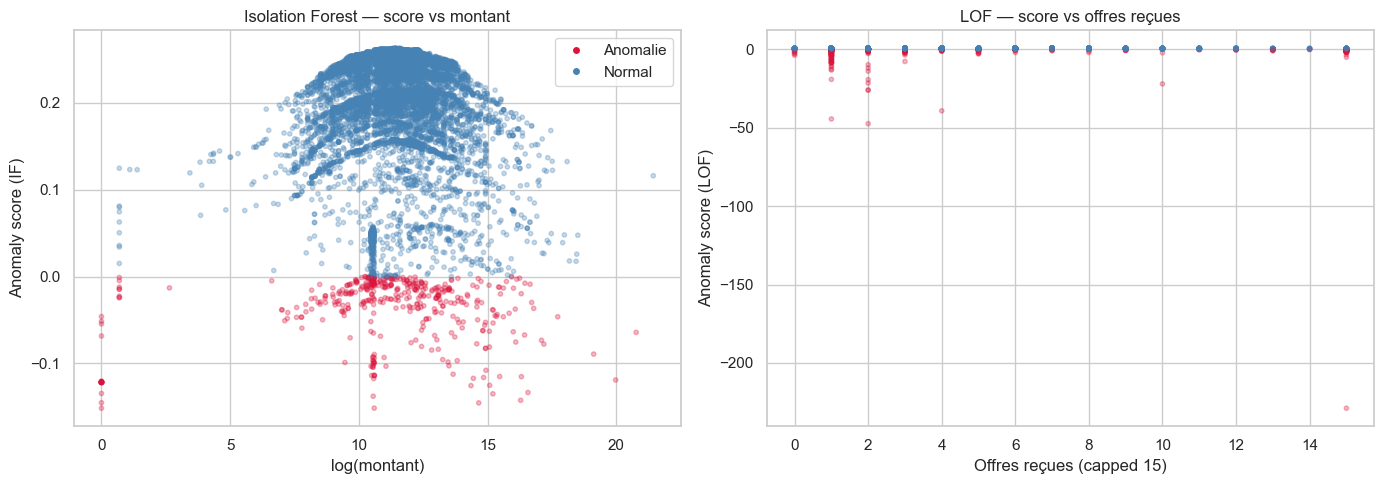

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score IF vs montant
colors = df['iso_pred'].map({1: 'steelblue', -1: 'crimson'})
axes[0].scatter(df['montant_log'], df['iso_score'], c=colors, alpha=0.3, s=10)
axes[0].set_xlabel('log(montant)')
axes[0].set_ylabel('Anomaly score (IF)')
axes[0].set_title('Isolation Forest — score vs montant')
axes[0].legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson', label='Anomalie'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Normal'),
])

# Score LOF vs offres reçues
colors2 = df['lof_pred'].map({1: 'steelblue', -1: 'crimson'})
axes[1].scatter(df['offresRecues'].clip(upper=15), df['lof_score'], c=colors2, alpha=0.3, s=10)
axes[1].set_xlabel('Offres reçues (capped 15)')
axes[1].set_ylabel('Anomaly score (LOF)')
axes[1].set_title('LOF — score vs offres reçues')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'anomaly_scores.png', dpi=150)
plt.show()

## 5. Top marchés les plus suspects

In [7]:
# Score normalisé combiné (moyenne des rangs)
df['iso_rank'] = df['iso_score'].rank()
df['lof_rank'] = df['lof_score'].rank()
df['combined_rank'] = (df['iso_rank'] + df['lof_rank']) / 2

top_suspects = df.nsmallest(15, 'combined_rank')[[
    'id', 'montant', 'procedure', 'offresRecues', 'dureeMois',
    'risk_score', 'iso_score', 'lof_score'
]]
print('=== Top 15 marchés les plus suspects ===')
print(top_suspects.to_string(index=False))

=== Top 15 marchés les plus suspects ===
            id   montant                                                    procedure  offresRecues  dureeMois  risk_score  iso_score  lof_score
2023-923192-01   38247.0                                            Procédure adaptée             4     4015.0           2  -0.137762 -39.224550
    24-1040910   39030.0                                            Procédure adaptée             1       60.0           2  -0.117444 -44.418748
       2024-04 2302903.0 Marché passé sans publicité ni mise en concurrence préalable            76       50.0           2  -0.145448  -5.040959
    24-1029636 5200000.0 Marché passé sans publicité ni mise en concurrence préalable             1       86.0           2  -0.115058  -7.791426
2021-832026-00   62790.0 Marché passé sans publicité ni mise en concurrence préalable             1       72.0           2  -0.103194  -6.426420
    24-1049702  700000.0 Marché passé sans publicité ni mise en concurrence préalable    

## 6. Sauvegarde des modèles

In [8]:
joblib.dump(iso_forest, MODELS_DIR / 'isolation_forest.pkl')
joblib.dump(lof, MODELS_DIR / 'lof.pkl')

print('Modèles sauvegardés :')
for f in MODELS_DIR.iterdir():
    print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')

Modèles sauvegardés :
  isolation_forest.pkl (1610 KB)
  lof.pkl (2895 KB)
